# Code for doing the different clustering methods, as well as data preprocessing

In this file we run the different methods

### DCEC - Deep Convolutional Embedded Clustering
First load the data

In [16]:
#  Loading the data with all 400 features (for 400x400 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "Input Data\\YoungAge_combined_run1_400_noZ_clean.mat"
fc_mat = loadmat(filepath)
fc_mat = fc_mat['run1_data']  # Extract the FC1 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (400, 400, N_subjects) for FC1
 # prints (N_subjects, 400, 400) for collected matrices

# fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 400, 400)
# fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 400, 400)

fc_mat_inv = fc_mat[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 400, 400)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 400, 400)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 400, 400)

# Expected shape is (Batch size, channels, height, width)

(71, 400, 400)
(71, 1, 400, 400)
Data shape: torch.Size([71, 1, 400, 400])


In [ ]:
#  Loading the data with all 1000 features (for 1000x1000 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "My_FC_matrices\\FC_O_run_1.mat"
fc_mat = loadmat(filepath)
print(fc_mat.keys())  # Print the keys to verify the structure of the loaded .mat file
fc_mat = fc_mat['run1_data']  # Extract the FC2 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (1000, 1000, N_subjects) for FC2
 # prints (N_subjects, 1000, 1000) for collected matrices

# fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 1000, 1000)
# fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 1000, 1000)

fc_mat_inv = fc_mat[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 1000, 1000)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 1000, 1000)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 1000, 1000)

# Expected shape is (Batch size, channels, height, width)

Define the autoencoder specs for the Convolutional Autoencoder (CAE)

In [1]:
# Names
# 400x400
name = "DCEC_400x400_71_Y_subjects_run1"

# 1000x1000
#name = "DCEC_1000x1000_68_O_subjects_run1"

In [2]:
# Config for 400x400 data
from Convolutional_AE import DCECConfig
cfg = DCECConfig(
    name=name,
    n_clusters=2,
    latent_dim=10,
    alpha=1.0,
    gamma=0.1,
    conv_layers_sizes=[1, 32, 64, 128, 256],
    epochs_pretrain=50,
    epochs_dcec=100,
    lr_pretrain=1e-3,
    lr_dcec=1e-3,
    update_interval=9, # Update target distribution every 9 batches, 9 batches in 71 subjects
    tol=4e-2, # 4e-2 = 0.04
    print_interval=10
)


Load the ran model and perform a last clustering

In [ ]:
# Load a model 
from Convolutional_AE import DCEC
import torch
from torch.utils.data import TensorDataset, DataLoader
from data_loader import set_seed

set_seed(42)

model_path = "Models\\model_DCEC_400x400_72_Y_subjects_run2_Cluster_2.pt"

model = DCEC(cfg)
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=3, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_z = []
all_labels = []

with torch.no_grad():
    for (batch,) in dataloader:
        x = batch.to(device)
        x_hat, q, z = model(x)

        labels = torch.argmax(q, dim=1)
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

z_all = np.concatenate(all_z, axis=0)
labels_all = np.concatenate(all_labels, axis=0)

print("z_all shape:", z_all.shape)  # Should be (N_subjects, latent_dim)
print("labels_all shape:", labels_all.shape)  # Should be (N_subjects,)

print("Labels:" , labels_all)

Run the DCEC Model - single run

In [ ]:
# Run the DCEC model once for the 200x200 data
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader

from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Pretraining
# ----------------------------------------------------------
set_seed(42)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DCEC(cfg=cfg).to(device)

pretrain_cae(model, dataloader, device, epochs=cfg.epochs_pretrain, lr=cfg.lr_pretrain, print_interval=cfg.print_interval)
y_pred_initial = initialize_cluster_centers(model, dataloader, device)
print("Early cluster centers initialized.", y_pred_initial)


# Saving the model
torch.save(model.state_dict(), f"Models\\pre_train_model_{cfg.name}.pt") 


In [ ]:
# Run the DCEC model once for the 200x200 data
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader

from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Training
# ----------------------------------------------------------
set_seed(42)

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DCEC(cfg=cfg).to(device)
model.load_state_dict(torch.load(f"Models\\pre_train_model_{cfg.name}.pt"))  # Load the pre-trained model weights


train_dcec(
    model,
    dataloader,
    device,
    gamma=cfg.gamma,
    epochs=cfg.epochs_dcec,
    lr=cfg.lr_dcec,
    update_interval=cfg.update_interval,
    tol=cfg.tol,
    print_interval=cfg.print_interval
    )

q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
print("Predicted cluster labels:", labels)

# Saving the model
torch.save(model.state_dict(), f"Models\\model_{cfg.name}.pt") 


Evaluate the clustering from a single run

In [ ]:
# Evaluate clustering performance of a single run
from Evaluate_models import evaluate_single_clustering

triu_idx = np.triu_indices(200, k=1)
fc_mat_transp = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)

Features = np.array([
    fc_mat_transp[i][triu_idx] for i in range(fc_mat_transp.shape[0])
]) 
predictions = labels

z = model.z
print("z shape:", z.shape)
print("predictions shape:", predictions.shape)

evaluate_single_clustering(Features, predictions)
evaluate_single_clustering(z, predictions)


In [ ]:
# Plot the model from one run
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg.n_clusters = 3  # Set the number of clusters to 3 for the latest model
model = DCEC(cfg=cfg).to(device)
model.load_state_dict(torch.load(f"Models/model_DCEC_200x200_clusters_3.pt"))  #


# Code for visualising the clustering results 
from Convolutional_AE import plot_training_history, plot_clustering, plot_reconstruction

plot_reconstruction(model, dataloader, device)
# plot_training_history(model)
plot_clustering(model, dataloader, device)

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_200x200_cluster", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results)




Run the DCEC model multiple times

In [19]:
# Pretraining - multiple
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Pretraining
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running DCEC for cluster {n_clusters} ...")
    pretrain_cae(
        model,
        dataloader,
        device,
        epochs=run_cfg.epochs_pretrain,
        lr=run_cfg.lr_pretrain,
        print_interval=run_cfg.print_interval
    )

    # Saving the model
    torch.save(model.state_dict(), f"Models\\pre_trained_model_{cfg.name}_Cluster_{n_clusters}.pt") 


Running DCEC for cluster 2 ...
[Pretrain] Epoch 001/50 - Recon loss: 0.124331
[Pretrain] Epoch 005/50 - Recon loss: 0.075522
[Pretrain] Epoch 010/50 - Recon loss: 0.073977
[Pretrain] Epoch 015/50 - Recon loss: 0.067291
[Pretrain] Epoch 020/50 - Recon loss: 0.055946
[Pretrain] Epoch 025/50 - Recon loss: 0.052534
[Pretrain] Epoch 030/50 - Recon loss: 0.049935
[Pretrain] Epoch 035/50 - Recon loss: 0.048859
[Pretrain] Epoch 040/50 - Recon loss: 0.046416
[Pretrain] Epoch 045/50 - Recon loss: 0.047156
[Pretrain] Epoch 050/50 - Recon loss: 0.044185
Running DCEC for cluster 3 ...
[Pretrain] Epoch 001/50 - Recon loss: 0.085280
[Pretrain] Epoch 005/50 - Recon loss: 0.066022
[Pretrain] Epoch 010/50 - Recon loss: 0.052799
[Pretrain] Epoch 015/50 - Recon loss: 0.044357
[Pretrain] Epoch 020/50 - Recon loss: 0.040464
[Pretrain] Epoch 025/50 - Recon loss: 0.038688
[Pretrain] Epoch 030/50 - Recon loss: 0.036795
[Pretrain] Epoch 035/50 - Recon loss: 0.036599
[Pretrain] Epoch 040/50 - Recon loss: 0.03535

In [20]:
# Training - multiple
from Convolutional_AE import DCEC, pretrain_cae, initialize_cluster_centers, train_dcec, predict_soft_assignments
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy
from data_loader import set_seed

# ----------------------------------------------------------
# DCEC - Deep Convolutional Embedded Clustering - Training
# ----------------------------------------------------------

set_seed(42)  # Set a fixed random seed for reproducibility

dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False) # Batch_size 8 gives 9 bacthes for 71 subjects. 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cluster_sizes =  list(range(2, 11)) # Example cluster sizes to evaluate

for n_clusters in cluster_sizes:
    run_cfg = deepcopy(cfg)  # Create a copy of the config for each run
    run_cfg.n_clusters = n_clusters
    
    model = DCEC(cfg=run_cfg).to(device)
    print(f"Running DCEC for cluster {n_clusters} ...")
    
    # Load the pre-trained model weights
    model.load_state_dict(torch.load(f"Models\\pre_trained_model_{cfg.name}_Cluster_{n_clusters}.pt"))  # Load the pre-trained model weights
    y_pred_initial = initialize_cluster_centers(model, dataloader, device)
    print("Early cluster centers initialized.", y_pred_initial)

    train_dcec(
        model,
        dataloader,
        device,
        gamma=run_cfg.gamma,
        epochs=run_cfg.epochs_dcec,
        lr=run_cfg.lr_dcec,
        update_interval=run_cfg.update_interval,
        tol=run_cfg.tol,
        print_interval=run_cfg.print_interval,
        # y_pred_initial=y_pred_initial
    )

    q_final, labels = predict_soft_assignments(model, dataloader, device, save=True)
    print("Predicted cluster labels:", labels)

    # Saving the model
    torch.save(model.state_dict(), f"Models\\model_{cfg.name}_Cluster_{n_clusters}.pt") 


Running DCEC for cluster 2 ...
Early cluster centers initialized. [0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 0 1 0
 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0]
[DCEC] Epoch 001/100 - Total: 0.064505, Recon: 0.051680, KL: 0.012825
Stopping early: cluster assignments stabilized. Delta: 0.008193832 < Tol: 0.04
Stopped at epoch 8 and batch 9 after 72 updates.
Predicted cluster labels: [0 0 0 0 1 1 1 0 1 0 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 1 1 0 1 0 0 1 0
 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0]
Running DCEC for cluster 3 ...
Early cluster centers initialized. [0 0 2 2 0 0 0 0 1 2 0 1 0 1 1 1 2 0 2 0 0 0 0 1 1 1 1 0 0 1 1 2 1 2 2 1 2
 2 1 1 1 0 2 1 2 0 0 1 0 2 2 1 0 0 1 1 0 2 0 1 1 0 0 1 0 0 1 1 0 1 0]
[DCEC] Epoch 001/100 - Total: 0.064142, Recon: 0.041558, KL: 0.022584
Stopping early: cluster assignments stabilized. Delta: 0.02105773 < Tol: 0.04
Stopped at epoch 6 and batch 9 after 54 updates.
Predicted cl

Evaluate the models from multiple cluster amounts

In [ ]:
# Print the clustering scores for all the runs 
from Evaluate_models import evaluate_single_clustering, Calculate_clustering_scores_from_folder
import os
import numpy as np

model_prefix = "DCEC_200x200_72_"
labels_tag = "_labels_predicted_labels_"
middle_layer_tag = "_middle_layer_predicted_labels_"

# Load the middle layer and predicted labels from the saved model
# Open the folder "Models"
Calculate_clustering_scores_from_folder(
    model_prefix = model_prefix,
    print_results = True
)

# Silhouett score: Higher is better
# Calinski-Harabasz score: Lower is better
# Davies-Bouldin score: Higher is better
        


In [ ]:
# PLot the results for all the runs
from Evaluate_models import plot_scores, Calculate_clustering_scores_from_folder
from Convolutional_AE import plot_clustering, DCEC
from torch.utils.data import TensorDataset, DataLoader
import os
import torch

results = Calculate_clustering_scores_from_folder(models_dir="Clusters", model_prefix="DCEC_400x400_72_O_subjects_run1_", labels_tag="_labels_predicted_labels_", middle_layer_tag="_middle_layer_predicted_labels_")
plot_scores(results, sort_scores=True, save_path="Figures\\DCEC_400x400_72_O_subjects_run1_clustering")

# Plot the clustering results for the models
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
for model in os.listdir("Models"):
    if model.startswith("model_DCEC_400x400_72_O_subjects_run1_"): # Only plot the models with the specified prefix
        print(f"\n Evaluating model: {model}")
        cluster_number = model.split("Cluster_")[1].split(".pt")[0]  # Extract the cluster number from the model name
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        cfg.n_clusters = int(cluster_number)  # Set the number of clusters to the extracted number
        temp_model = DCEC(cfg=cfg).to(device)   
        temp_model.load_state_dict(torch.load(f"Models/{model}"))
        
        plot_clustering(temp_model, dataloader, device, save_path =f"Figures\\{model}.png")


Only one cluster in the provided labels, silhouette coefficient not computed.
Plot saved to: Figures\Clustering Scores Plot\DCEC_400x400_68_O_subjects_run1_clustering_scores_plot.png


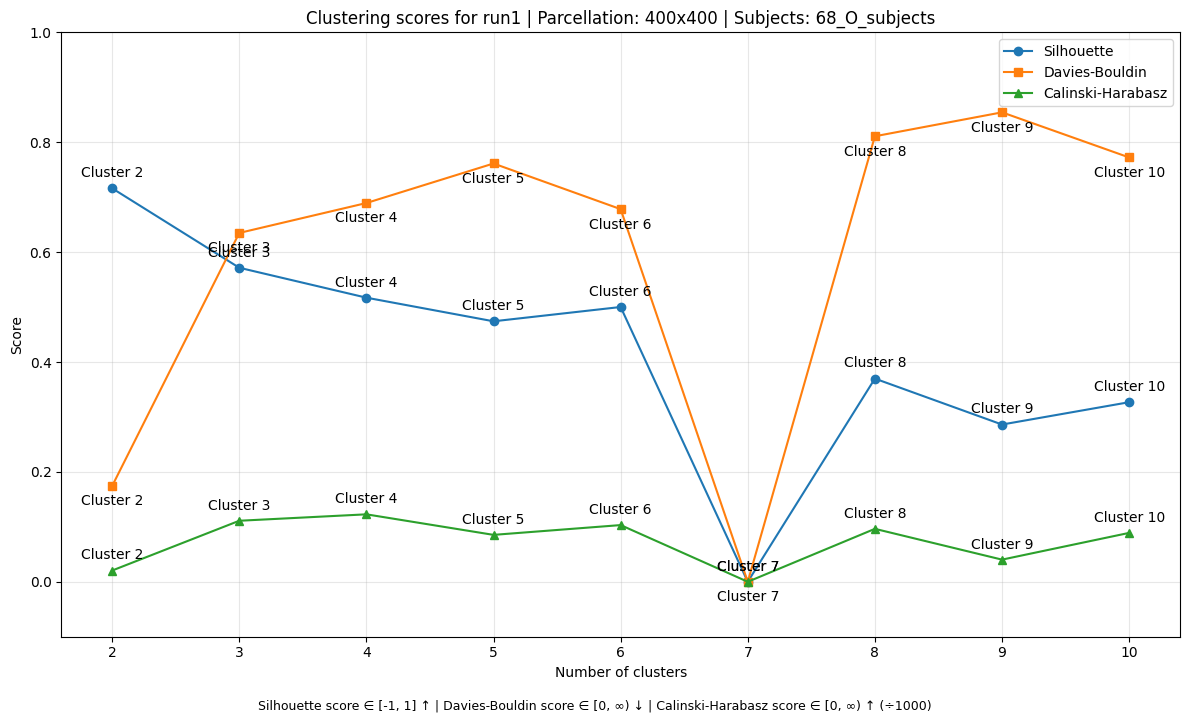

In [10]:
# Plot the clustering results for the models together
from Evaluate_models import plot_clustering_scores_sorted

clustering_dir = "Clusters"
model_prefix = "DCEC_400x400_68_O_subjects_run1_"
labels_tag = "_labels_predicted_labels_"
middle_layer_tag = "_middle_layer_predicted_labels_"
save_path = rf"Figures\Clustering Scores Plot\{model_prefix}clustering_scores_plot.png"

results = plot_clustering_scores_sorted(models_dir=clustering_dir, model_prefix=model_prefix, labels_tag=labels_tag, middle_layer_tag=middle_layer_tag, ytop=1.0, save_path=save_path)

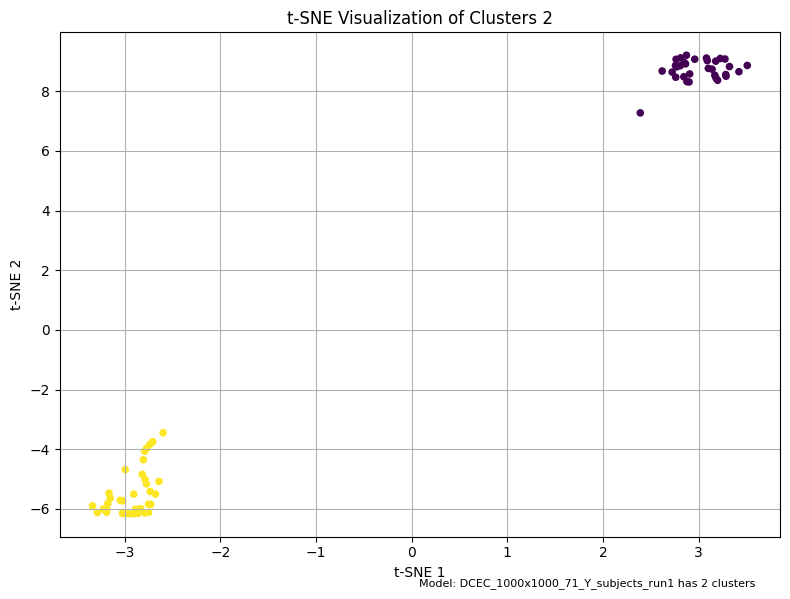

In [4]:
# Do tsne for the best cluster for each run
from Convolutional_AE import plot_clustering, DCEC
from torch.utils.data import TensorDataset, DataLoader
import torch
from scipy.io import loadmat

n_clusters = 2
model = rf"model_DCEC_1000x1000_71_Y_subjects_run1_Cluster_{n_clusters}"
filepath = "My_FC_matrices\\FC_Y_run_1.mat"  # "Input Data\\OldAge_combined_run1_400_noZ_clean.mat"  #    #
name = "DCEC_1000x1000_71_Y_subjects_run1"

cfg.n_clusters = n_clusters
cfg.name = name
fc_mat = loadmat(filepath)
fc_mat = fc_mat['run1_data'] 
fc_mat_inv = fc_mat[:, None, :, :]
X = torch.from_numpy(fc_mat_inv).float()  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False)
temp_model = DCEC(cfg=cfg).to(device)
temp_model.load_state_dict(torch.load(rf"Models\{model}.pt"))  # Load the pre-trained model weights

plot_clustering(temp_model, dataloader, device, save_path =f"Figures\\Clustering results t-SNE visualization\\{model}.png")

### UMAP

In [ ]:
from UMAP import UMAP

### HDBSCAN
Perform HDBSCAN on the data

In [ ]:
from My_HDBSCAN import hdbscan_clustering

hdbscan_clustering(Functional_connectivity_matrix=Functional_connectivity_matrix, save_labels=True)

### Evaluate clustering against behavioural data

In [4]:
from data_loader import load_whole_behavioural_data, combine_cca_mlr_pipeline_outputs, convert_numpy
from Evaluate_clusterings_with_CCA import full_cca_selection_subject_pipeline
from Evaluate_clusterings_with_MLR import full_mlr_selection_subject_pipeline
import json

# Load data
#csv_path = "C:\\Users\\oddar\\Downloads\\Beh.csv"
csv_path = "C:\\Users\\oddafo\\Downloads\\Combined_Beh_Cognitive.csv"

used_ids_path = "Dummy Test Data\\Included_subjects_Old.csv"
cluster_labels_path = "Clusters\\DCEC_400x400_68_O_subjects_run1_" # Prefix for the cluster labels files

df, included_variables = load_whole_behavioural_data(csv_path=csv_path, included_ids_path=used_ids_path, cluster_labels_path=cluster_labels_path)

# Define parameters
cluster_col = ""
subject_id_col = "Subject"
Old_run1_output_dict = {}
no_subjects = df.shape[0]

for cluster in range(2, 11):
    cluster_col = f"Cluster_{cluster}"
    n_splits = 5
    
    # Check if the current clustering is flat
    n_unique = df[cluster_col].dropna().nunique()
    if n_unique < 2:
        print(f"\n\n=== Skipping {cluster_col} due to insufficient unique clusters (n={n_unique}) ===")
        Old_run1_output_dict[cluster_col+"_results"] = {
            "cca_removed_subjects_results": {
                "mean_correlation": None,
                "removed_subjects": None
            },
            "mlr_removed_subjects_results": {
                "mean_accuracy": None,
                "removed_subjects": None
            }
        }
        continue
    
    # Check if the current clustering contains too small clusters
    cluster_counts = df[cluster_col].dropna().value_counts()
    min_cluster_size = cluster_counts.min()
    if min_cluster_size < 2 and cluster_col == "Cluster_2": 
        print(f"\n\n=== Skipping {cluster_col} due to small cluster size (min cluster size={min_cluster_size}) ===")
        Old_run1_output_dict[cluster_col+"_results"] = {
            "cca_removed_subjects_results": {
                "mean_correlation": None,
                "removed_subjects": None
            },
            "mlr_removed_subjects_results": {
                "mean_accuracy": None,
                "removed_subjects": None
            }
        }
        continue

    n_splits = max(min(n_splits, min_cluster_size), 3)  # Adjust n_splits based on the smallest cluster size

    print(f"\n\n=== Running pipelines for {cluster_col} ===")
    # Run pipelines
    print("Running CCA pipeline...")
    pipeline_output_cca = full_cca_selection_subject_pipeline(
        data=df,
        cluster_col=cluster_col,
        candidate_variables=included_variables,
        cv_splits=5,
        random_state=42,
        max_variables=6,
        min_improvement=0.01,
        subject_id_col=subject_id_col,
        print_results=False
    )
    print("Running MLR pipeline...")
    pipeline_output_mlr = full_mlr_selection_subject_pipeline(
        data=df,
        cluster_col=cluster_col,
        candidate_variables=included_variables,
        cv_splits=5,
        random_state=42,
        max_variables=10,
        min_improvement=0.01,
        subject_id_col=subject_id_col,
        print_results=False
    )

    # Combine results
    print("Combining results")
    combined_results = combine_cca_mlr_pipeline_outputs(pipeline_output_cca, pipeline_output_mlr)
    print(f"MLR final results: {combined_results['mlr_removed_subjects_results']['mean_accuracy']:.4f}")

    Old_run1_output_dict[cluster_col+"_results"] = combined_results

# Save results to JSON
with open("Results\\400x400_Old_run1_cluster_behavioural_results.json", "w") as f:
    json.dump(Old_run1_output_dict, f, indent=4, default=convert_numpy)



=== Skipping Cluster_2 due to small cluster size (min cluster size=1) ===


=== Running pipelines for Cluster_3 ===
Running CCA pipeline...


c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cross_decomposition\_pls.py:328: RuntimeWarning: invalid value encountered in divide
  x_loadings = np.dot(x_scores, Xk) / np.dot(x_scores, x_scores)
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cross_decomposition\_pls.py:333: RuntimeWarning: invalid value encountered in divide
  y_loadings = np.dot(y_scores, yk) / np.dot(y_scores, y_scores)


Running MLR pipeline...
Combining results
MLR final results: 0.6275


=== Running pipelines for Cluster_4 ===
Running CCA pipeline...
Running MLR pipeline...
Combining results
MLR final results: 0.4484


=== Running pipelines for Cluster_5 ===
Running CCA pipeline...
Running MLR pipeline...
Combining results
MLR final results: 0.4330


=== Running pipelines for Cluster_6 ===
Running CCA pipeline...
Running MLR pipeline...
Combining results
MLR final results: 0.3418


=== Skipping Cluster_7 due to insufficient unique clusters (n=1) ===


=== Running pipelines for Cluster_8 ===
Running CCA pipeline...
Stopping: cluster sizes too small for CV (smallest cluster size=1).
Running MLR pipeline...


c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_s

c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_s

...

c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^

c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  

c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_s

Combining results
MLR final results: 1.0000


c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^

### Plot the behavioural analysis results

In [ ]:
from Evaluate_models import plot_cca_mlr_across_clusters

json_path = "Results\\1000x1000_Young_run1_cluster_behavioural_results.json"
save_path = r"Figures\\CCA and MLR scores across clusters\\1000x1000_Young_run1_cluster_metric_relationship.png"

results = plot_cca_mlr_across_clusters(json_path, title="CCA vs MLR Performance for 1000x1000 Young Run 1", save_path=save_path)

In [ ]:
from Evaluate_models import plot_single_cluster_cca_mlr_variants

json_path = "Results\\1000x1000_Young_run1_cluster_behavioural_results.json"
ideal_cluster_number = "8"  # Set this to the cluster number you want to plot
save_path = rf"Figures\\CCA and MLR scores for best cluster\\1000x1000_Young_run1_cluster_{ideal_cluster_number}_metric_relationship.png"
title = f"CCA vs MLR Performance for Cluster {ideal_cluster_number} in 1000x1000 parcellation - Young Run 1"

results = plot_single_cluster_cca_mlr_variants(json_path=json_path, cluster_number=ideal_cluster_number, save_path=save_path, title=title)

In [ ]:
# Compare the common variables and removed subjects across clusters
from Evaluate_models import compare_common_across_clusters, print_comparison_summary

file_id = "1000x1000_Young_run1"
json_path = rf"Results\\{file_id}_cluster_behavioural_results.json"
variable_keys = ["cca_selected_variables", "mlr_selected_variables"]
removed_subjects_keys = ["cca_removed_subjects", "mlr_removed_subjects"]
save_path = rf"Figures\\Common variables and removed subjects - Clusters\\{file_id}_common_variables.txt"

results_across_clusters = compare_common_across_clusters(json_path=json_path, variable_keys=variable_keys, removed_subjects_keys=removed_subjects_keys)
print_comparison_summary(results_across_clusters, save_path=save_path)

In [ ]:
# Compare the common variables and removed subjects across clusters
from Evaluate_models import compare_common_across_runs_same_cluster, print_comparison_summary

Age = "Young"
cluster_number = "3"  # Set this to the cluster number you want to compare across runs

json_paths = [rf"Results\\1000x1000_{Age}_run1_cluster_behavioural_results.json", rf"Results\\{Age}_run1_cluster_behavioural_results.json",  rf"Results\\{Age}_run2_cluster_behavioural_results.json"]
variable_keys = ["cca_selected_variables", "mlr_selected_variables"]
removed_subjects_keys = ["cca_removed_subjects", "mlr_removed_subjects"]
save_path = rf"Figures\\Common variables and removed subjects - Across\\{Age}_subjects_cluster_{cluster_number}_common_variables.txt"

results_across_clusters = compare_common_across_runs_same_cluster(json_paths=json_paths, variable_keys=variable_keys, removed_subjects_keys=removed_subjects_keys, cluster_number=cluster_number)
print_comparison_summary(results_across_clusters, save_path=save_path)

In [ ]:
from Evaluate_models import plot_cca_mlr_two_jsons_across_clusters

run_num = 2

young_path = rf"Results\\Young_run{run_num}_cluster_behavioural_results.json"
old_path = rf"Results\\Old_run{run_num}_cluster_behavioural_results.json"
save_path = rf"Figures\\Comparison young and old\\run{run_num}_behavioural_age_comprison.png"
title = rf"Comparison of CCA and MLR across ages for run {run_num}"

results = plot_cca_mlr_two_jsons_across_clusters(old_json_path=old_path, young_json_path=young_path, title=title, save_path=save_path)

In [ ]:

from Evaluate_models import count_occurrences_across_two_jsons, print_comparison_summary
import json
run_num = 1

young_path = rf"Results\\Young_run{run_num}_cluster_behavioural_results.json"
old_path = rf"Results\\Old_run{run_num}_cluster_behavioural_results.json"
save_path = rf"Figures\Common variables and removed subjects - Across age\\run{run_num}_behavioural_age_comprison.txt"

results = count_occurrences_across_two_jsons(young_json_path=young_path, old_json_path=old_path)
print(results["counts_sorted"])

save_results = {
    "young_json_path": young_path,
    "old_json_path": old_path,
    "counts_sorted": results["counts_sorted"]
}

with open(save_path, "w", encoding="utf-8") as f:
    json.dump(save_results, f, indent=4)
print(f"\nComparison result saved to: {save_path}")